# Pose Training Pipeline Visualization (Predicted Keypoints)

This notebook visualizes one random sample from cached Stage-2 predicted keypoints (`exports/stage3_predicted_keypoints.pt`) through the Stage-3 pose-classification pipeline:
1. normalized keypoint sample
2. keypoint visibility and coordinate diagnostics
3. inference using exported best model
4. class-probability visualization
5. full-dataset evaluation on predicted keypoint features

## Setup

In [2]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "training":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.pose_predicted_dataset import pose_predicted_dataset
from models.pose_classification import PoseClassificationModel

FEATURE_PATH = PROJECT_ROOT / "saved_models" / "stage3_predicted_keypoints.pt"
CLASS_NAMES = ["backhand", "forehand", "ready_position", "serve"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Predicted keypoint feature path: {FEATURE_PATH}")
if not FEATURE_PATH.exists():
    raise FileNotFoundError(f"Missing feature file: {FEATURE_PATH}")

Project root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Predicted keypoint feature path: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/saved_models/stage3_predicted_keypoints.pt


## 1) Random Sample Keypoints

Random sample from cached Stage-2 predicted keypoint features (`stage3_predicted_keypoints.pt`) visualized in normalized coordinate space.

Dataset label order: ['Backhand', 'Forehand', 'Ready_Position', 'Serve']
Total samples in predicted feature dataset: 2000


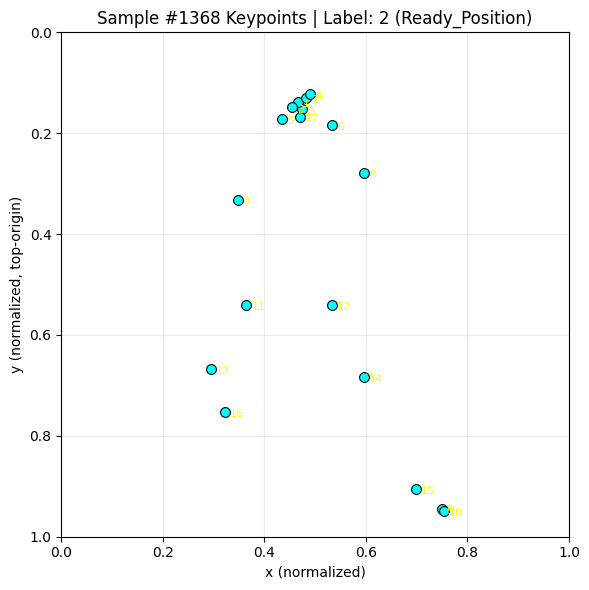

Sample keypoints shape: (18, 3)
Visible keypoints: 18 / 18
x range: (0.29411765933036804, 0.7529411911964417)
y range: (0.12156862765550613, 0.9490196108818054)


In [3]:
feature_payload = torch.load(FEATURE_PATH, map_location="cpu")
if not isinstance(feature_payload, dict):
    raise ValueError("Unexpected feature payload format. Expected dict.")

pose_dataset = pose_predicted_dataset(str(FEATURE_PATH))
dataset_label_names = feature_payload.get("label_names", CLASS_NAMES)
if dataset_label_names is None or len(dataset_label_names) == 0:
    dataset_label_names = CLASS_NAMES

print("Dataset label order:", dataset_label_names)
print(f"Total samples in predicted feature dataset: {len(pose_dataset)}")

sample_idx = random.randrange(len(pose_dataset))
sample_keypoints_t, sample_label_t = pose_dataset[sample_idx]
sample_keypoints = sample_keypoints_t.numpy()  # (18, 3)
sample_label_idx = int(sample_label_t.item())
sample_label_name = (
    dataset_label_names[sample_label_idx]
    if sample_label_idx < len(dataset_label_names)
    else f"class_{sample_label_idx}"
)

visible_mask = sample_keypoints[:, 2] > 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    sample_keypoints[visible_mask, 0],
    sample_keypoints[visible_mask, 1],
    c="cyan",
    s=50,
    edgecolors="black",
    linewidths=0.8,
)
for i in np.where(visible_mask)[0]:
    xk, yk = sample_keypoints[i, 0], sample_keypoints[i, 1]
    ax.text(xk + 0.01, yk + 0.01, str(i), color="yellow", fontsize=8)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(1.0, 0.0)
ax.set_xlabel("x (normalized)")
ax.set_ylabel("y (normalized, top-origin)")
ax.set_title(f"Sample #{sample_idx} Keypoints | Label: {sample_label_idx} ({sample_label_name})")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Sample keypoints shape:", sample_keypoints.shape)
print("Visible keypoints:", int(visible_mask.sum()), "/", sample_keypoints.shape[0])
print("x range:", (float(sample_keypoints[:, 0].min()), float(sample_keypoints[:, 0].max())))
print("y range:", (float(sample_keypoints[:, 1].min()), float(sample_keypoints[:, 1].max())))

## 2) Normalized Keypoint Matrix Diagnostics

Inspect the `(18,3)` feature matrix used by the Stage-3 classifier.

Keypoint matrix (rows=joint index, cols=[x_norm, y_norm, visibility]):
[[0.4745098  0.15294118 2.4821186 ]
 [0.46666667 0.13725491 2.0430624 ]
 [0.48235294 0.12941177 2.3643355 ]
 [0.45490196 0.14901961 2.4727252 ]
 [0.49019608 0.12156863 2.6014721 ]
 [0.43529412 0.17254902 3.1659484 ]
 [0.53333336 0.18431373 2.5123575 ]
 [0.34901962 0.33333334 2.2707884 ]
 [0.59607846 0.2784314  1.3564194 ]
 [0.7490196  0.94509804 2.7541046 ]
 [0.7529412  0.9490196  2.9410827 ]
 [0.3647059  0.5411765  4.291763  ]
 [0.53333336 0.5411765  3.731403  ]
 [0.29411766 0.6666667  3.901402  ]
 [0.59607846 0.68235296 4.2413573 ]
 [0.69803923 0.90588236 3.1231368 ]
 [0.32156864 0.7529412  2.6836572 ]
 [0.47058824 0.16862746 2.1705077 ]]


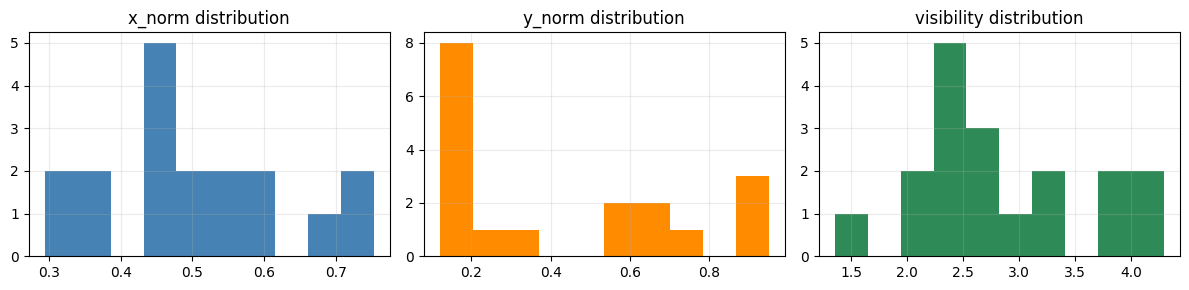

In [4]:
print("Keypoint matrix (rows=joint index, cols=[x_norm, y_norm, visibility]):")
print(sample_keypoints)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(sample_keypoints[:, 0], bins=10, color="steelblue")
axes[0].set_title("x_norm distribution")
axes[1].hist(sample_keypoints[:, 1], bins=10, color="darkorange")
axes[1].set_title("y_norm distribution")
axes[2].hist(sample_keypoints[:, 2], bins=10, color="seagreen")
axes[2].set_title("visibility distribution")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3) Inference with Exported Best Model

Loads pose model from `exports/` first, with checkpoint fallback.

In [5]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

export_ckpt = PROJECT_ROOT / "exports" / "pose_best_predicted.pt"
fallback_ckpt = PROJECT_ROOT / "checkpoints" / "pose_best_predicted.pt"
if export_ckpt.exists():
    checkpoint_path = export_ckpt
elif fallback_ckpt.exists():
    checkpoint_path = fallback_ckpt
else:
    raise FileNotFoundError(f"No predicted-keypoint pose checkpoint found. Checked: {export_ckpt} and {fallback_ckpt}")

device = get_device()
checkpoint = torch.load(checkpoint_path, map_location=device)

args = checkpoint.get("args", {}) if isinstance(checkpoint, dict) else {}
hidden_dim = args.get("hidden_dim", 256)
dropout = args.get("dropout", 0.25)
visibility_threshold = args.get("visibility_threshold", 0.0)

pose_model = PoseClassificationModel(
    num_keypoints=18,
    num_classes=4,
    hidden_dim=hidden_dim,
    dropout=dropout,
    visibility_threshold=visibility_threshold,
).to(device)

if isinstance(checkpoint, dict) and "model_state" in checkpoint:
    state_dict = checkpoint["model_state"]
else:
    state_dict = checkpoint
pose_model.load_state_dict(state_dict)
pose_model.eval()

model_input = sample_keypoints_t.unsqueeze(0).to(device)

with torch.no_grad():
    probs = pose_model(model_input).squeeze(0).detach().cpu().numpy()

checkpoint_label_names = checkpoint.get("label_names", None) if isinstance(checkpoint, dict) else None
if isinstance(checkpoint_label_names, list) and len(checkpoint_label_names) == len(probs):
    label_names_for_display = checkpoint_label_names
elif isinstance(dataset_label_names, list) and len(dataset_label_names) == len(probs):
    label_names_for_display = dataset_label_names
else:
    label_names_for_display = [f"class_{i}" for i in range(len(probs))]

pred_idx = int(np.argmax(probs))
pred_name = label_names_for_display[pred_idx] if pred_idx < len(label_names_for_display) else f"class_{pred_idx}"
true_name = (
    label_names_for_display[sample_label_idx]
    if sample_label_idx < len(label_names_for_display)
    else f"class_{sample_label_idx}"
)

print(f"Loaded model from: {checkpoint_path}")
print("Label names used for display:", label_names_for_display)
print(f"True label: {sample_label_idx} ({true_name})")
print(f"Pred label: {pred_idx} ({pred_name})")
print("Probabilities:", probs)

Loaded model from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/pose_best_predicted.pt
Label names used for display: ['Backhand', 'Forehand', 'Ready_Position', 'Serve']
True label: 2 (Ready_Position)
Pred label: 2 (Ready_Position)
Probabilities: [0.01152069 0.00825226 0.978222   0.00200498]


## 4) Class Probability Diagnostics

Visualize predicted probability distribution for the selected sample.

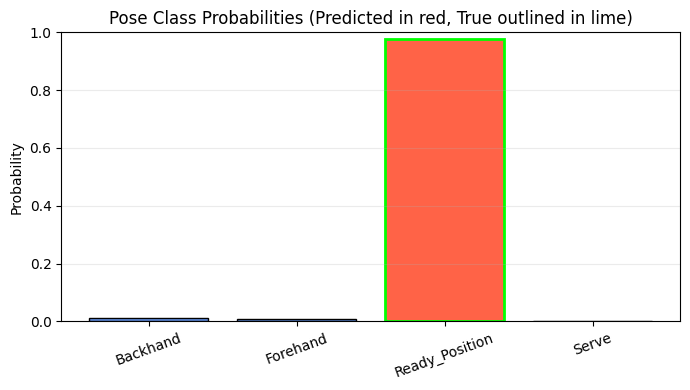

Top-2 classes:
1. 2 (Ready_Position): 0.9782
2. 0 (Backhand): 0.0115


In [6]:
if "label_names_for_display" in globals() and len(label_names_for_display) == len(probs):
    class_labels = label_names_for_display
else:
    class_labels = [f"class_{i}" for i in range(len(probs))]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_labels, probs, color="cornflowerblue", edgecolor="black")
bars[pred_idx].set_color("tomato")
if sample_label_idx < len(bars):
    bars[sample_label_idx].set_edgecolor("lime")
    bars[sample_label_idx].set_linewidth(2.0)

ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Probability")
ax.set_title("Pose Class Probabilities (Predicted in red, True outlined in lime)")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

top2_idx = np.argsort(probs)[-2:][::-1]
print("Top-2 classes:")
for rank, idx in enumerate(top2_idx, start=1):
    name = class_labels[idx]
    print(f"{rank}. {idx} ({name}): {probs[idx]:.4f}")

## Evaluation

Measure accuracy on the full predicted-keypoint feature dataset (`stage3_predicted_keypoints.pt`).

In [7]:
# Evaluate accuracy on full predicted-keypoint feature dataset
n_samples = len(pose_dataset)

def evaluate_subset(indices, batch_size=256):
    subset = torch.utils.data.Subset(pose_dataset, indices.tolist() if hasattr(indices, "tolist") else list(indices))
    loader = torch.utils.data.DataLoader(subset, batch_size=batch_size, shuffle=False)

    correct, total = 0, 0
    class_correct = np.zeros(len(label_names_for_display), dtype=np.int64)
    class_total = np.zeros(len(label_names_for_display), dtype=np.int64)

    pose_model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = pose_model(x)
            pred = out.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.numel()

            y_cpu = y.detach().cpu().numpy()
            p_cpu = pred.detach().cpu().numpy()
            for t, p in zip(y_cpu, p_cpu):
                class_total[t] += 1
                if p == t:
                    class_correct[t] += 1

    acc = correct / total if total > 0 else 0.0
    class_acc = np.divide(
        class_correct,
        np.maximum(class_total, 1),
        dtype=np.float64,
    )
    return acc, class_correct, class_total, class_acc

all_indices = np.arange(n_samples)
acc, c_ok, c_n, c_acc = evaluate_subset(all_indices)

print(f"Total samples: {n_samples}")
print(f"Accuracy: {acc:.4f}")

print("\nPer-class accuracy:")
for i, name in enumerate(label_names_for_display):
    print(f"- {i} ({name}): {c_acc[i]:.4f} ({c_ok[i]}/{c_n[i]})")

Total samples: 2000
Accuracy: 0.8820

Per-class accuracy:
- 0 (Backhand): 0.9080 (454/500)
- 1 (Forehand): 0.7880 (394/500)
- 2 (Ready_Position): 0.9300 (465/500)
- 3 (Serve): 0.9020 (451/500)
